Predicting the price of a house based on its surface area

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import root_mean_squared_error, r2_score

import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
# -------------------------
# Load Dataset
# -------------------------
df = pd.read_csv('prix_maisons.csv')

In [3]:
df

,area,price
0,100,1218000
1,120,1440000
2,150,1800000
3,260,2860000
4,320,2880000


In [4]:

df.shape

(5, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,5.0,190.0,95.393920,100.0,120.0,150.0,260.0,320.0
price,5.0,2039600.0,786015.775923,1218000.0,1440000.0,1800000.0,2860000.0,2880000.0


In [7]:
df.isna().sum()

area     0
price    0
dtype: int64

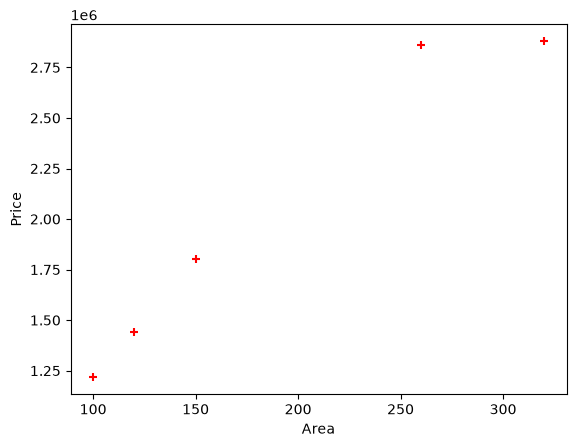

In [8]:
# -------------------------
# Visualization
# -------------------------
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df['area'], df['price'], color='red', marker="+")

In [10]:
# -------------------------
# Train Model
# -------------------------
lr = linear_model.LinearRegression()

In [11]:
y = df['price']
X = df.drop(columns=['price'])

In [12]:
lr.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8026.92]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.145e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [16]:
# -------------------------
# Prediction
# -------------------------
predicted_price =lr.predict([[2300]]) 
print(predicted_price.tolist()[0])

18976407.692307692


d:\python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
# -------------------------
# Evaluation
# -------------------------
predicted = lr.predict(X)

In [18]:
print("Predicted => ",predicted)
print ("Target => ", y.tolist())

Predicted =>  [1317176.92307692 1477715.38461538 1718523.07692308 2601484.61538462
 3083100.        ]
Target =>  [1218000, 1440000, 1800000, 2860000, 2880000]


In [19]:
r2_score(y, predicted)

0.9490237236328821

In [20]:
root_mean_squared_error(y, predicted)

158730.47305707596

In [24]:
# -------------------------
# Equation
# -------------------------
intercept= lr.intercept_
coef = lr.coef_

In [26]:
price1 = intercept + coef * 1000
price2 = lr.predict([[1000]])
print("\nFormula Prediction (1000 sqft):")
print(price1)
print("\nModel Prediction (1000 sqft):")
print(price2)


Formula Prediction (1000 sqft):
[8541407.69230769]

Model Prediction (1000 sqft):
[8541407.69230769]


d:\python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Linear Regression')

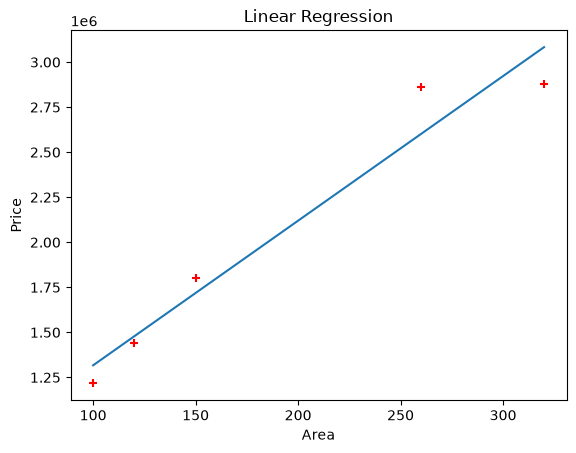

In [27]:
# -------------------------
# Regression Line
# -------------------------
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df['area'], df['price'], color='red', marker="+")
plt.plot(df['area'], lr.predict(df[['area']]))
plt.title("Linear Regression")

Predicting the price of a house based on its size, number of bedrooms, age, and neighborhood

In [39]:
# Load Dataset
df2 = pd.read_csv('prix_maisons2.csv')
df2

,area,rooms,age,city,price
0,100,3.0,4,Tunis,1500000
1,120,4.0,10,Tunis,1680000
2,260,NaN,20,Tunis,3380000
3,190,5.0,1,Tunis,3040000
4,260,5.0,4,Tunis,3900000
5,60,2.0,3,Tunis,1080000
6,100,3.0,4,Sfax,1400000
7,120,4.0,10,Sfax,1580000
8,260,5.0,20,Sfax,3280000
9,190,5.0,1,Sfax,2900000


In [40]:
df2.shape

(18, 5)

In [41]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    18 non-null     int64  
 1   rooms   15 non-null     float64
 2   age     18 non-null     int64  
 3   city    18 non-null     str    
 4   price   18 non-null     int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 852.0 bytes


In [42]:
df2.describe()

,area,rooms,age,price
count,18.00000,15.000000,18.00000,1.800000e+01
mean,165.00000,3.800000,7.00000,2.276667e+06
std,79.64997,1.207122,6.61549,9.947450e+05
min,60.00000,2.000000,1.00000,8.600000e+05
25%,100.00000,3.000000,3.00000,1.485000e+06
50%,155.00000,4.000000,4.00000,2.290000e+06
75%,260.00000,5.000000,10.00000,3.030000e+06
max,260.00000,5.000000,20.00000,3.900000e+06


In [43]:
df2.isna().sum()

area     0
rooms    3
age      0
city     0
price    0
dtype: int64

In [44]:
median = df2['rooms'].median()
print(median)

4.0


In [45]:
df2['rooms']=df2['rooms'].fillna(median)
df2

,area,rooms,age,city,price
0,100,3.0,4,Tunis,1500000
1,120,4.0,10,Tunis,1680000
2,260,4.0,20,Tunis,3380000
3,190,5.0,1,Tunis,3040000
4,260,5.0,4,Tunis,3900000
5,60,2.0,3,Tunis,1080000
6,100,3.0,4,Sfax,1400000
7,120,4.0,10,Sfax,1580000
8,260,5.0,20,Sfax,3280000
9,190,5.0,1,Sfax,2900000


In [46]:
df2['city'].value_counts()

city
Tunis     6
Sfax      6
Sousse    6
Name: count, dtype: int64

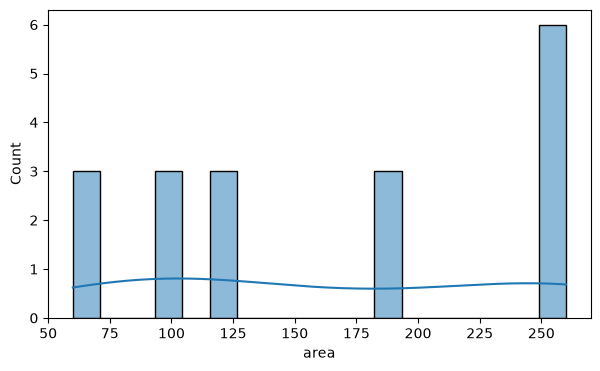

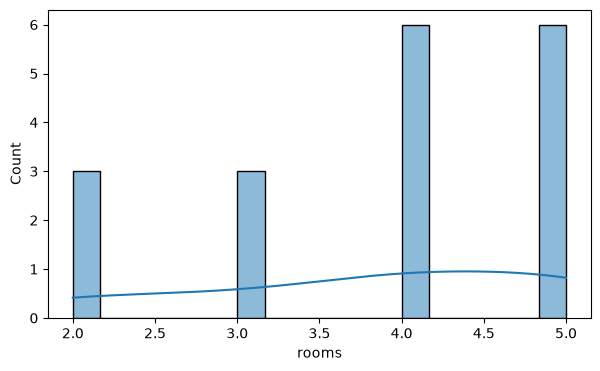

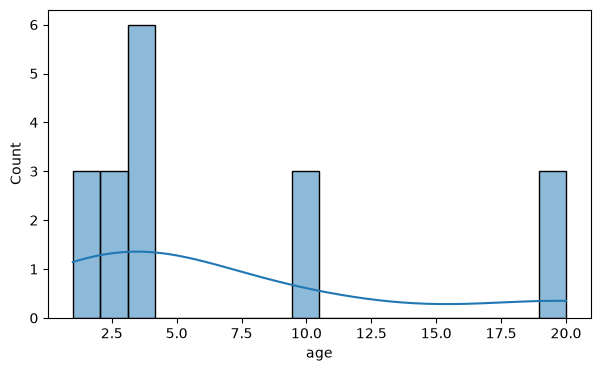

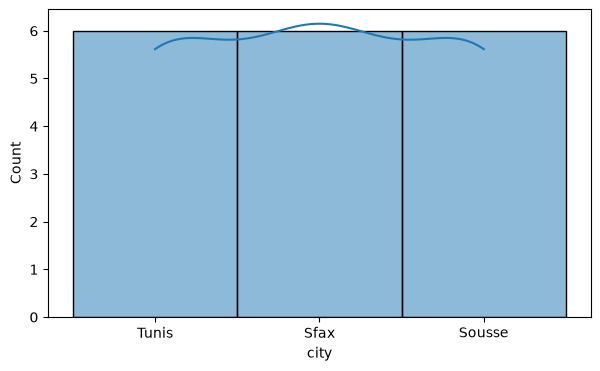

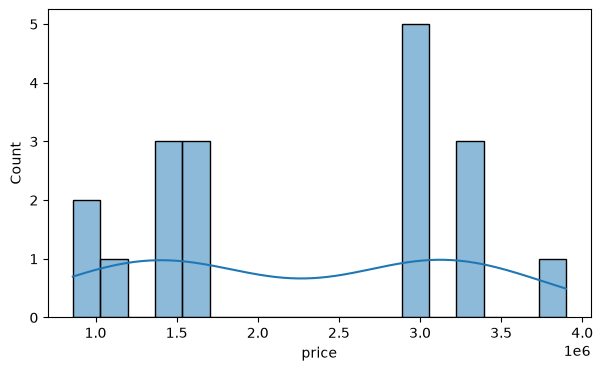

In [36]:
for col in df2.columns:
   plt.figure(figsize = (7, 4))
   sns.histplot(data = df2, x = col, kde = True, bins=18)
plt.show()

In [47]:
label_encoder = LabelEncoder()
dummy_df = pd.get_dummies(df2['city'], drop_first=False, prefix='city')

In [48]:
df2 = pd.concat([df2, dummy_df], axis=1)

In [49]:
df2


,area,rooms,age,city,price,city_Sfax,city_Sousse,city_Tunis
0,100,3.0,4,Tunis,1500000,False,False,True
1,120,4.0,10,Tunis,1680000,False,False,True
2,260,4.0,20,Tunis,3380000,False,False,True
3,190,5.0,1,Tunis,3040000,False,False,True
4,260,5.0,4,Tunis,3900000,False,False,True
5,60,2.0,3,Tunis,1080000,False,False,True
6,100,3.0,4,Sfax,1400000,True,False,False
7,120,4.0,10,Sfax,1580000,True,False,False
8,260,5.0,20,Sfax,3280000,True,False,False
9,190,5.0,1,Sfax,2900000,True,False,False


<Axes: xlabel='area', ylabel='age'>

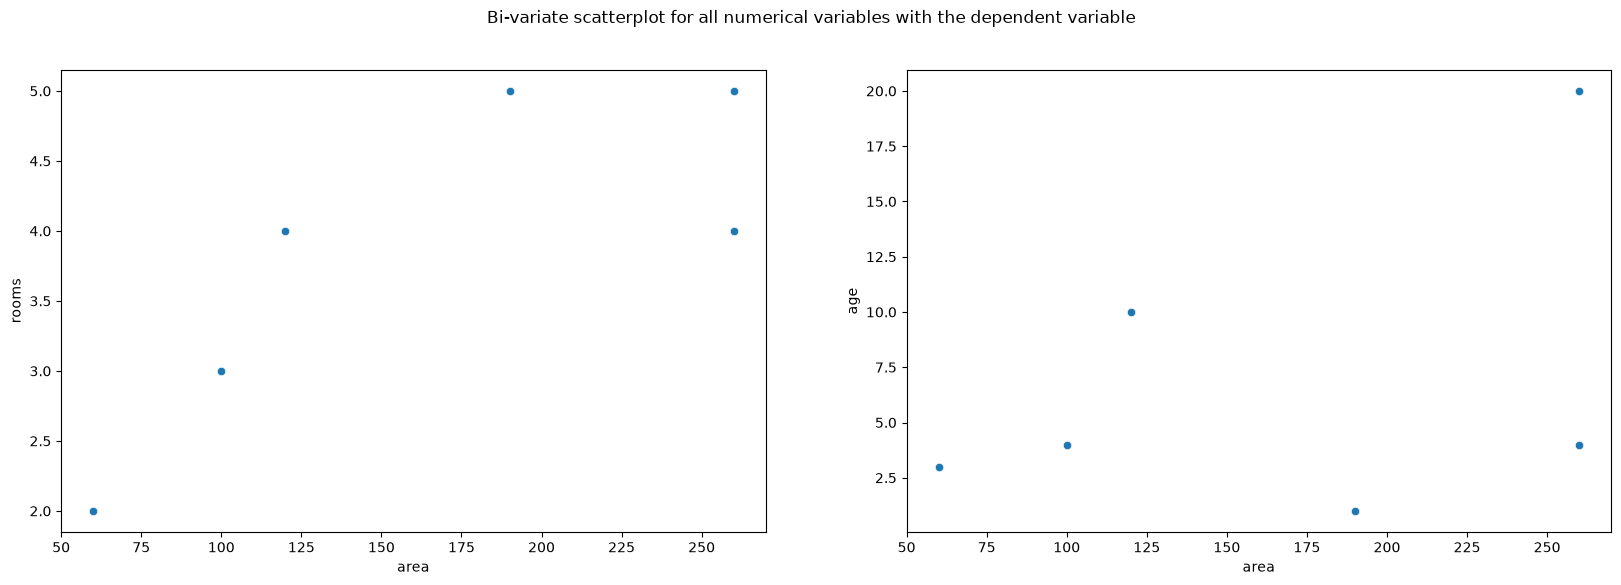

In [51]:
fig, axes = plt.subplots(1, 2, figsize = (20, 6))
  
fig.suptitle('Bi-variate scatterplot for all numerical variables with the dependent variable')
  
sns.scatterplot(x = 'area', y = 'rooms', data = df2, ax = axes[0])

sns.scatterplot(x = 'area', y = 'age', data = df2, ax = axes[1])

In [52]:
outcome = df2['price']
features = df2.drop(columns=['price','city'])

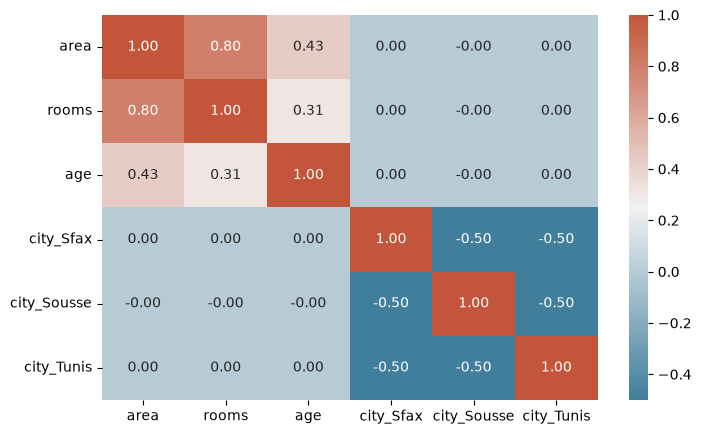

In [53]:
plt.figure(figsize = (8, 5))
cmap = sns.diverging_palette(230, 20, as_cmap = True)
sns.heatmap(features.corr(), annot = True, fmt = '.2f', cmap = cmap )
plt.show()

In [54]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(features, outcome, test_size = 0.3, random_state = 1)

In [55]:
# create the model
regressor = linear_model.LinearRegression()

In [56]:
# training the model
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 8626.12,310819.44,-19758.09,-59418.96,-27996.9 , 87415.86]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['area','rooms','age','city_Sfax','city_Sousse','city_Tunis']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.961e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [57]:
# prediction
preds_train = regressor.predict(X_train)

In [58]:
# model evaluation
r2_score(y_train, preds_train)

0.9760647063979758

In [59]:
preds_test = regressor.predict(X_test)

In [60]:
r2_score(y_test, preds_test)

0.9324022925175757

In [61]:
regressor.coef_

array([  8626.11742769, 310819.43745123, -19758.08760919, -59418.96096589,
       -27996.89556964,  87415.85653553])

In [62]:
regressor.intercept_

np.float64(-196079.78040406434)

In [63]:
regressor.predict([[2600,3,20,False, False, True]])

d:\python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([22856537.94828253])